In [100]:
# Add the relevant scripts from LArMachineLearningData
# Nice the process so it can run with lots of cores on low priority
import os
os.nice(20)

# Add local paths
import sys
hnlDIR = os.environ['_']
sys.path.append('../pyscript')
sys.path.append('../bdtscript')

# From BDT Library
from importlib import reload
from PandoraBDT import *

# Import relevant SKLearn stuff
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import validation_curve
from sklearn.model_selection import learning_curve
from sklearn import metrics

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [101]:
# Set background and signal label names
params = {
    'labelNames': ['Background','Signal'],
    'signalDefs': [0, 1],
    'signalCols': ['r', 'b']
}

featureNames = ['slc_vtx_x',
 'slc_vtx_y',
 'slc_vtx_z',
 'slc_crumbs_score',
 'slc_opt0_score',
 'slc_opt0_frac',
 'slc_opt0_time_corrected_Z_pandora',
 'slc_n_razzled_electrons',
 'slc_n_razzled_muons',
 'slc_n_razzled_photons',
 'slc_n_razzled_pions_thresh',
 'slc_n_razzled_protons_thresh',
 'slc_pfp_n_hits',
 'slc_pfp_track_score',
 'slc_pfp_razzled_electron_score',
 'slc_pfp_razzled_muon_score',
 'slc_pfp_razzled_photon_score',
 'slc_pfp_razzled_pion_score',
 'slc_pfp_razzled_proton_score',
 'slc_pfp_track_length',
 'slc_pfp_track_ke',
 'slc_pfp_track_angle_to_beam',
 'slc_pfp_shower_conv_gap',
 'slc_pfp_shower_length',
 'slc_pfp_shower_open_angle',
 'slc_pfp_shower_energy',
 'slc_pfp_shower_dedx',
 'slc_pfp_shower_angle_to_beam']

In [102]:
input_max_depth = 3
input_n_trees = 300

# Create the base BDT to vary the params from and compare to
baseBDT = AdaBoostClassifier(DecisionTreeClassifier(max_depth=input_max_depth),algorithm='SAMME', 
                         random_state=42, n_estimators=input_n_trees)

# Split the data into many subsets to grid search over (Set seed for reproducibility)
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

In [103]:
# Load the training data
trainingFile = './training.csv'

data, nFeatures, nExamples = LoadData(trainingFile, ',')
print(nFeatures)
print(nExamples)
print(np.shape(data)[1])

28
2177523
29


In [104]:
data[3]

array([ 1.17118645e+02, -1.50202621e+02,  4.13939178e+02,  6.61889600e-01,
        1.48776872e+04,  5.17459533e-02,  9.04173749e+02,  0.00000000e+00,
        0.00000000e+00,  2.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        1.24200000e+03,  3.60112040e-01,  3.44127240e-01,  3.33834700e-03,
        6.49485770e-01,  2.55819700e-03,  4.90460200e-04,  2.11632380e+02,
        8.56932250e+02,  5.92486954e+00,  1.95331946e+00,  6.89274723e+01,
        2.36339593e-01,  4.95457528e+02,  8.29688319e+00,  6.43453360e+00,
        1.00000000e+00])

In [105]:
featuresOrg, labelsOrg = SplitTrainingSet(data, nFeatures)
features, labels = Randomize(featuresOrg, labelsOrg, True)

# Split into train and test samples
testTrainFraction = 0.8
xTrain, yTrain, xTest, yTest = Sample(features, labels, testTrainFraction)

# Split into signal and background based on the true labels
signalFeatures = features[labels==1]
backgroundFeatures = features[labels==0]

# Check the features arry is the same size as the feature names array
print (len(featureNames))
print (np.shape(features))
print('Total: '+str(len(features))+', signal: '+
      str(len(signalFeatures))+' and background: '+
      str(len(backgroundFeatures)))

28
(75087, 28)
Total: 75087, signal: 19008 and background: 56079


In [106]:
# Construct the Pandas dataframe
# First crete a dictionary
allDict = {featureNames[i]: features[:, i] for i in range(nFeatures)}
allDict.update({'Labels': labels})

# Create the Pandas dataframe, create seperate df for signal/background
df = pd.DataFrame(data=allDict)

/home/php19vcn/HNL_study/HNLPiZero_Selection/BDT_notebook/../bdtscript/PandoraBDT.py:28: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots()


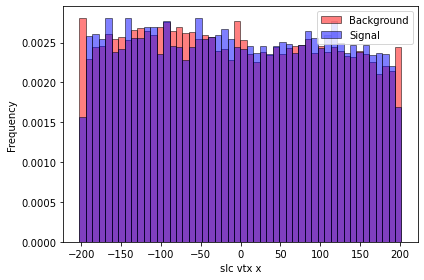

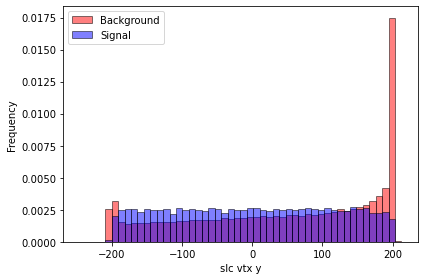

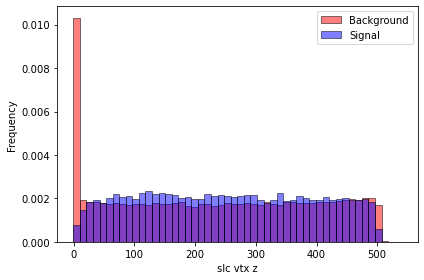

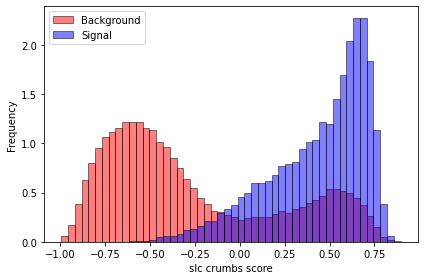

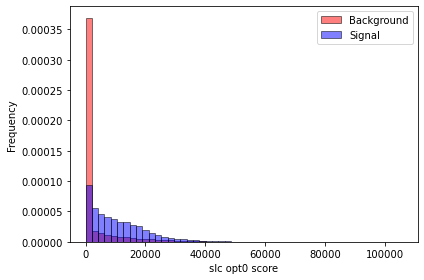

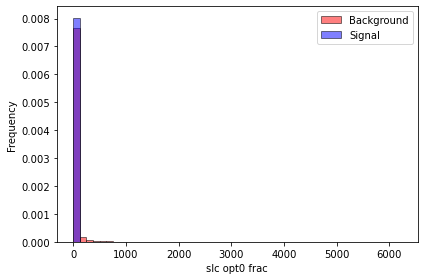

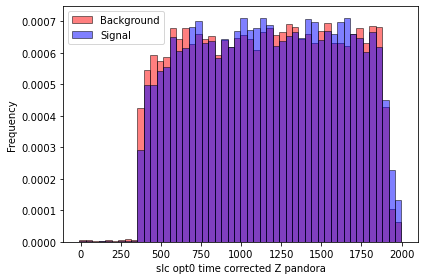

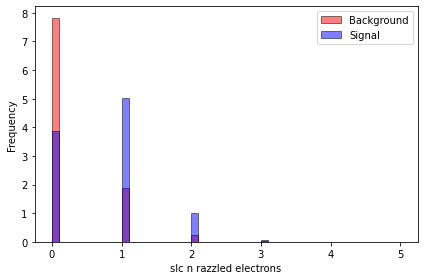

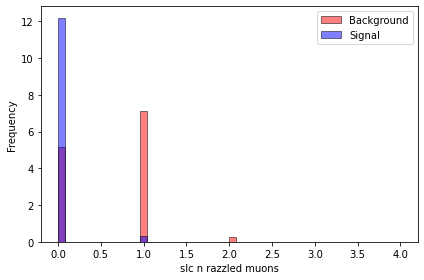

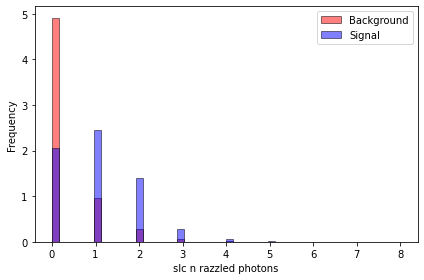

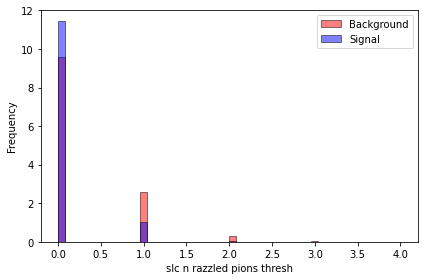

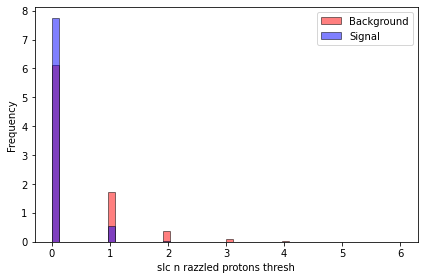

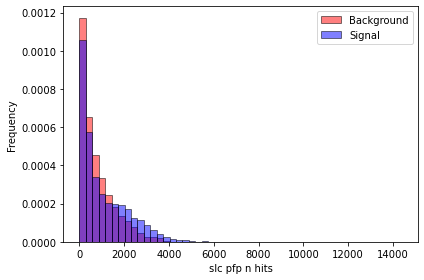

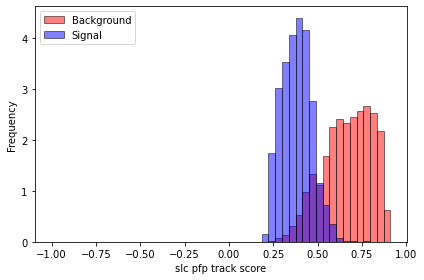

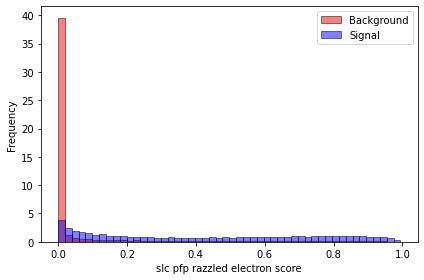

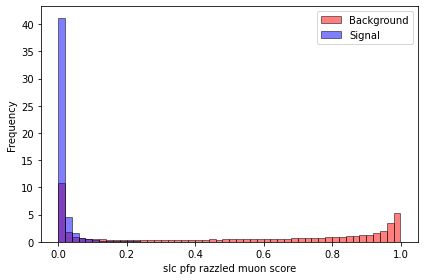

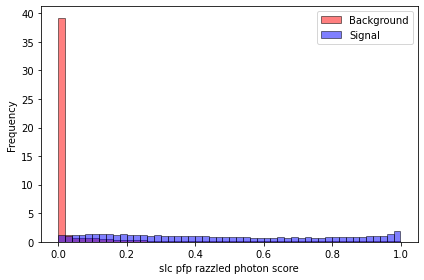

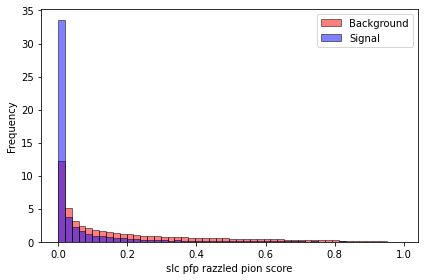

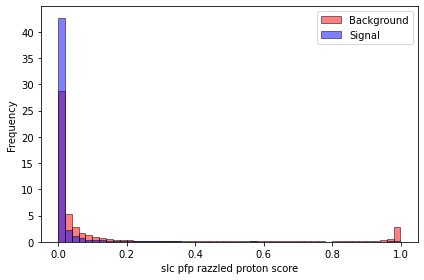

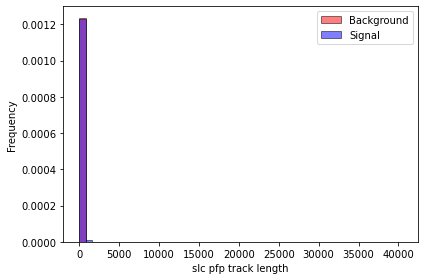

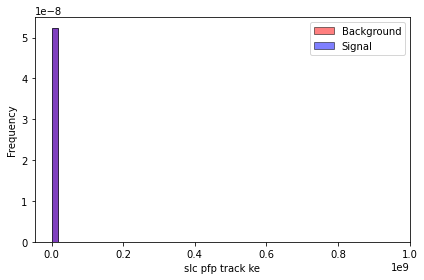

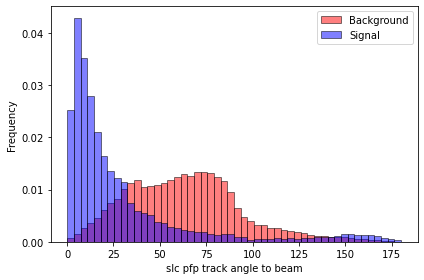

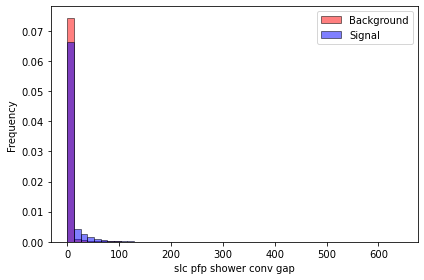

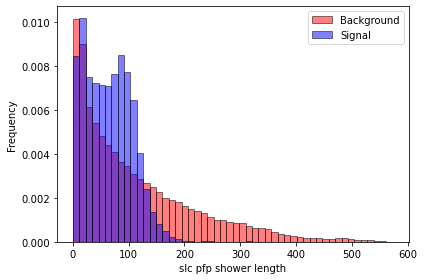

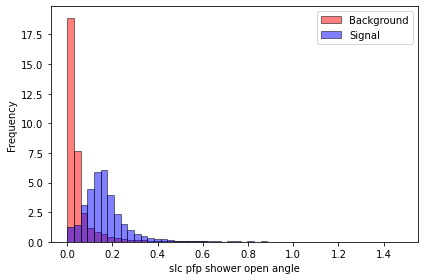

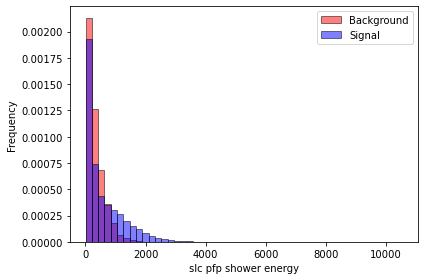

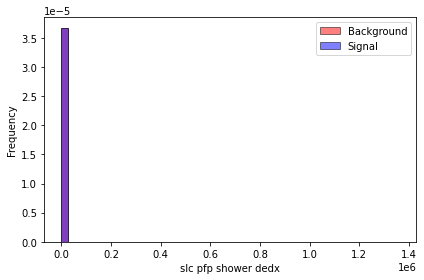

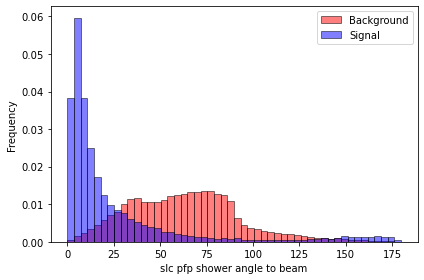

In [107]:
# Make plots drawing the variables for signal/background
plt.rcParams['axes.facecolor'] = 'white'
DrawVariablesDF(df, params, saveFig = False)

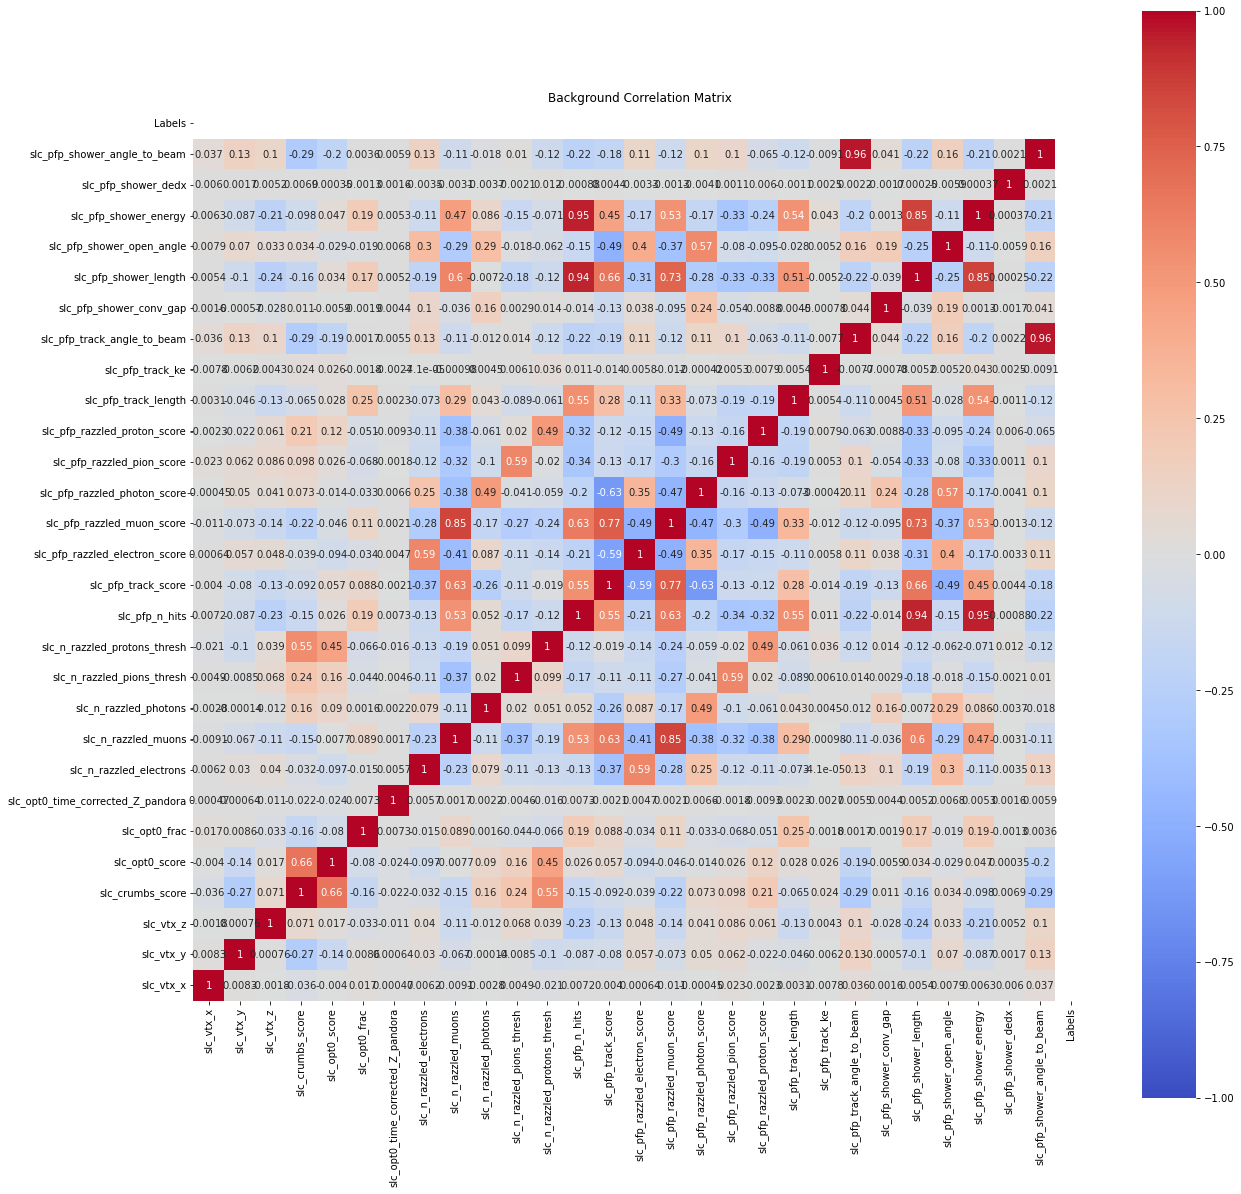

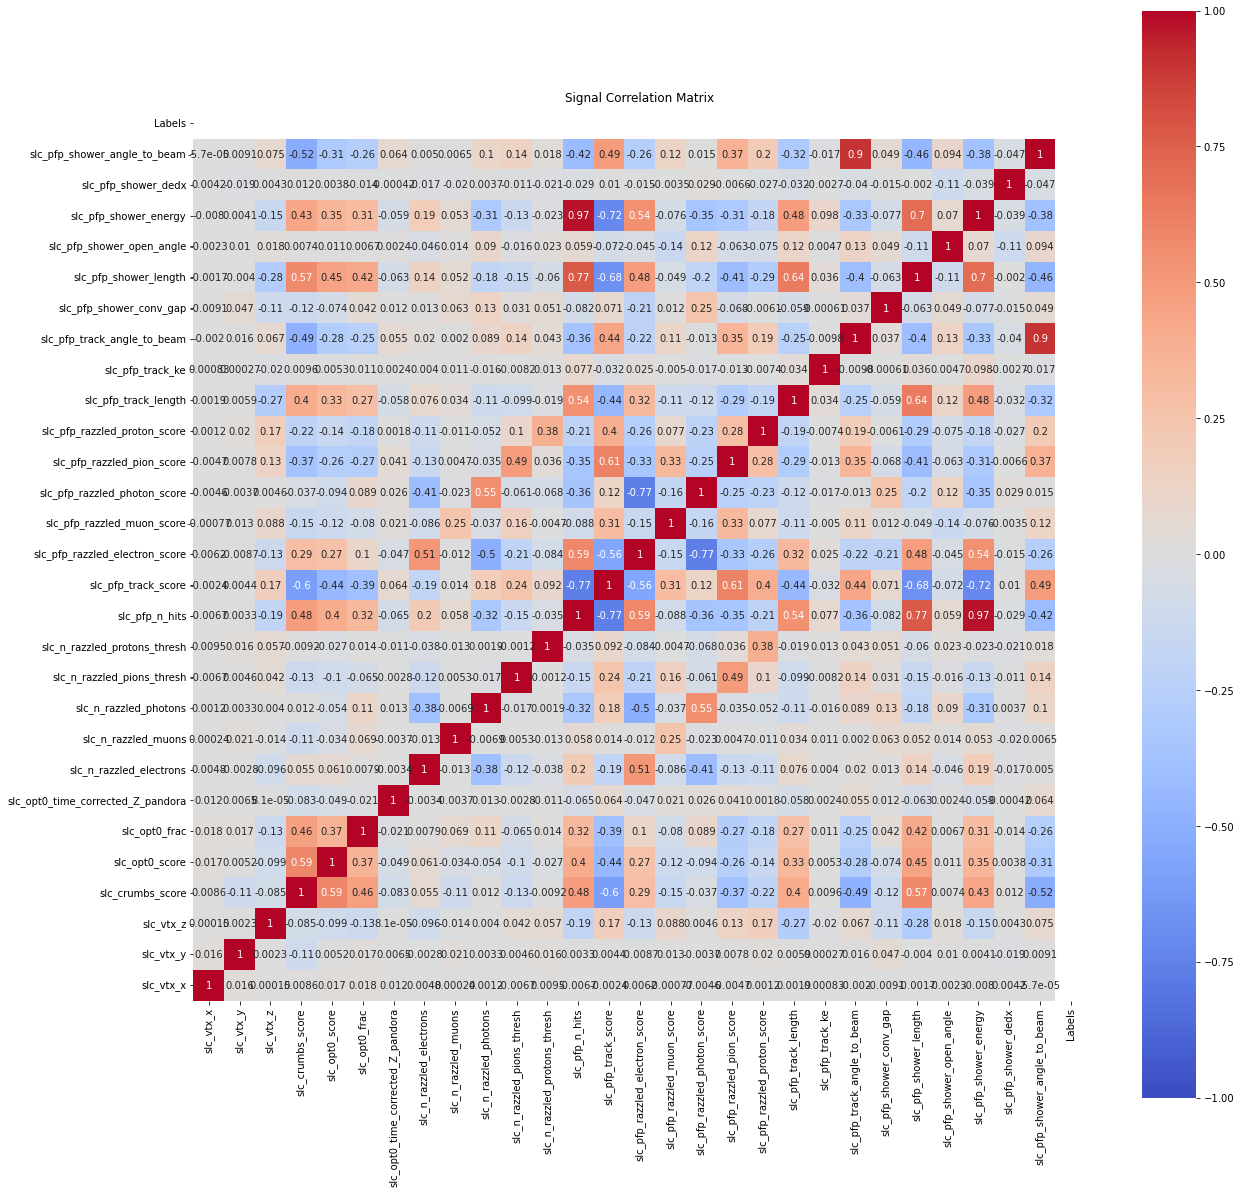

In [108]:
# Make correlation matricies
Correlation(df[df['Labels']==params['signalDefs'][0]], params['labelNames'][0] + ' Correlation Matrix')
Correlation(df[df['Labels']==params['signalDefs'][1]], params['labelNames'][1] + ' Correlation Matrix')

In [109]:
# Define size of grid search
depthRange = 4
treeRange = 4

# Set up ranges for grid search
depthArray = np.linspace(1, depthRange, depthRange, dtype=int)
treeArray = np.linspace(50, 150,treeRange,dtype=int)

# Print arrays for debugging
print ("Depth Array:", depthArray)
print ("Tree Array: ", treeArray)

# Construct a dictionary to loop over
paramGrid = dict(base_estimator__max_depth=depthArray, n_estimators=treeArray)

print(paramGrid)
# Perform the grid search
nCores = -1
grid = GridSearchCV(baseBDT, param_grid=paramGrid, cv=cv, n_jobs=nCores, 
                    verbose=9, refit=True, return_train_score=True)


Depth Array: [1 2 3 4]
Tree Array:  [ 50  83 116 150]
{'base_estimator__max_depth': array([1, 2, 3, 4]), 'n_estimators': array([ 50,  83, 116, 150])}


In [110]:
# Run the grid search
grid.fit(xTrain, yTrain)

print("The best parameters are %s with a score of %0.2f"% 
      (grid.best_params_, grid.best_score_))

# Put the output of the grid in a conveneant df
gridResults = pd.DataFrame(grid.cv_results_)
gridResults.rename(columns={"param_base_estimator__max_depth": "MaxDepth"}, inplace=True)
gridResults.rename(columns={"param_n_estimators": "NTrees"}, inplace=True)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
The best parameters are {'base_estimator__max_depth': 4, 'n_estimators': 83} with a score of 0.97


In [111]:
testScores = gridResults.pivot("MaxDepth", "NTrees", "mean_test_score")
testStd = gridResults.pivot("MaxDepth", "NTrees", "std_test_score")
trainScores = gridResults.pivot("MaxDepth", "NTrees", "mean_train_score")

/home/php19vcn/miniconda3/envs/rootenv/lib/python3.9/site-packages/pandas/core/algorithms.py:798: FutureWarning: In a future version, the Index constructor will not infer numeric dtypes when passed object-dtype sequences (matching Series behavior)
  uniques = Index(uniques)


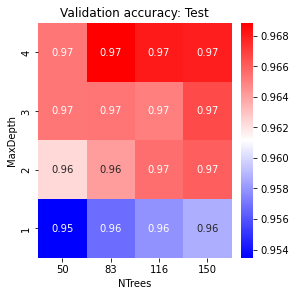

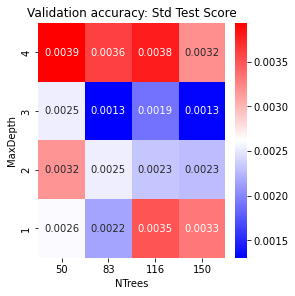

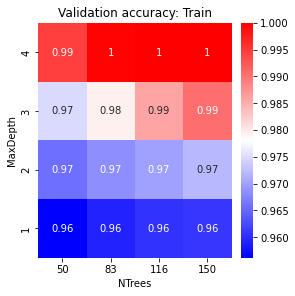

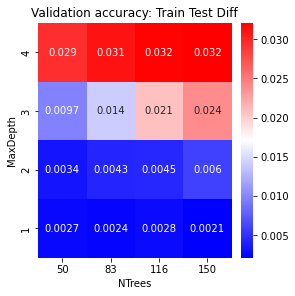

NTrees         50        83        116       150
MaxDepth                                        
1         0.950760  0.954321  0.955103  0.956601
2         0.958913  0.959811  0.961059  0.960027
3         0.955516  0.951204  0.944228  0.942729
4         0.935953  0.937883  0.936085  0.935819
0.9610594292933651


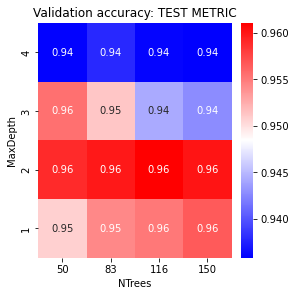

In [112]:
trainTestDiff = trainScores - testScores

saveFig = True

plt.figure(figsize=(4, 4), constrained_layout=True)
sns.heatmap(testScores, cmap='bwr', linewidths=0, annot=True)
plt.title('Validation accuracy: Test')
plt.gca().invert_yaxis()
if saveFig:
    plt.savefig('TestScores.png')
plt.show()

plt.figure(figsize=(4, 4), constrained_layout=True)
sns.heatmap(testStd, cmap='bwr', linewidths=0, annot=True)
plt.title('Validation accuracy: Std Test Score')
plt.gca().invert_yaxis()
if saveFig:
    plt.savefig('TrainStds.png')
plt.show()

plt.figure(figsize=(4, 4), constrained_layout=True)
sns.heatmap(trainScores, cmap='bwr', linewidths=0, annot=True)
plt.title('Validation accuracy: Train')
plt.gca().invert_yaxis()
if saveFig:
    plt.savefig('TrainScores.png')
plt.show()

plt.figure(figsize=(4, 4), constrained_layout=True)
sns.heatmap(trainTestDiff, cmap='bwr', linewidths=0, annot=True)
plt.title('Validation accuracy: Train Test Diff')
plt.gca().invert_yaxis()
if saveFig:
    plt.savefig('TrainTestDiff.png')
plt.show()

# This is my attempt at trying to finds a metric that maximises performance whilst
# minimising overtraining without haveing to do a KS test
myTestMetric = testScores - abs(trainTestDiff)

print (myTestMetric)
print (myTestMetric.max().max())

plt.figure(figsize=(4, 4), constrained_layout=True)
sns.heatmap(myTestMetric, cmap='bwr', linewidths=0, annot=True)
plt.title('Validation accuracy: TEST METRIC')
plt.gca().invert_yaxis()
if saveFig:
    plt.savefig('test.png')
plt.show()

In [113]:
# Reference BDT with controlled hyperparams : Put it in the baseBDT above
input_max_depth = 2
input_n_trees = 50
baseBDT = AdaBoostClassifier(DecisionTreeClassifier(max_depth=input_max_depth),algorithm='SAMME', 
                         random_state=42, n_estimators=input_n_trees)
baseBDT.fit(xTrain,yTrain)

AdaBoostClassifier(algorithm='SAMME',
                   base_estimator=DecisionTreeClassifier(max_depth=2),
                   random_state=42)

In [114]:
# Reference BDT with controlled hyperparams : Put it in the baseBDT above
input_max_depth = 2
input_n_trees = 80
baseBDT2 = AdaBoostClassifier(DecisionTreeClassifier(max_depth=input_max_depth),algorithm='SAMME', 
                         random_state=42, n_estimators=input_n_trees)
baseBDT2.fit(xTrain,yTrain)

AdaBoostClassifier(algorithm='SAMME',
                   base_estimator=DecisionTreeClassifier(max_depth=2),
                   n_estimators=80, random_state=42)

/home/php19vcn/miniconda3/envs/rootenv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_roc_curve is deprecated; Function :func:`plot_roc_curve` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: :meth:`sklearn.metrics.RocCurveDisplay.from_predictions` or :meth:`sklearn.metrics.RocCurveDisplay.from_estimator`.
  warnings.warn(msg, category=FutureWarning)
/home/php19vcn/miniconda3/envs/rootenv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_roc_curve is deprecated; Function :func:`plot_roc_curve` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: :meth:`sklearn.metrics.RocCurveDisplay.from_predictions` or :meth:`sklearn.metrics.RocCurveDisplay.from_estimator`.
  warnings.warn(msg, category=FutureWarning)
/home/php19vcn/miniconda3/envs/rootenv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_roc_curve is deprec

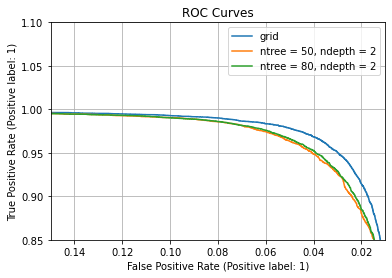

In [116]:
# Plot ROC curves
fig, ax = plt.subplots()
metrics.plot_roc_curve(grid, xTest, yTest, ax=ax, label = 'grid')
metrics.plot_roc_curve(baseBDT, xTest, yTest, ax=ax, label = 'ntree = 50, ndepth = 2')
metrics.plot_roc_curve(baseBDT2, xTest, yTest, ax=ax, label = 'ntree = 80, ndepth = 2')
plt.title("ROC Curves")
plt.xlim(0.01, 0.15)
plt.ylim(0.85, 1.1)
ax.invert_xaxis()
ax.legend()
ax.grid()

/home/php19vcn/miniconda3/envs/rootenv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


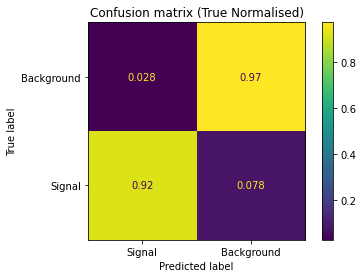

In [118]:
# Plot Confusion Matricies
fig, ax = plt.subplots()
metrics.plot_confusion_matrix(baseBDT2, xTest, yTest, display_labels=params['labelNames'],
                             ax=ax, normalize='true')
ax.invert_xaxis()
#ax.invert_zaxis()
plt.title("Confusion matrix (True Normalised)")
plt.show()

In [119]:
# Print more detailed performance info
bdtPredicted = baseBDT.predict(xTest)
#gridPredicted = grid.predict(xTest)

print ("Background (0): ", params['labelNames'][0])
print ("Signal (1): ", params['labelNames'][1])
print ("BDT:\n", metrics.classification_report(yTest, bdtPredicted))
#print ("Grid:\n", metrics.classification_report(yTest, gridPredicted))

Background (0):  Background
Signal (1):  Signal
BDT:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97     44857
           1       0.92      0.92      0.92     15213

    accuracy                           0.96     60070
   macro avg       0.95      0.95      0.95     60070
weighted avg       0.96      0.96      0.96     60070



                             Features  Importance Score
9               slc_n_razzled_photons          0.000000
7             slc_n_razzled_electrons          0.000000
23              slc_pfp_shower_length          0.000000
14     slc_pfp_razzled_electron_score          0.000046
18       slc_pfp_razzled_proton_score          0.003134
0                           slc_vtx_x          0.006259
22            slc_pfp_shower_conv_gap          0.009463
12                     slc_pfp_n_hits          0.011523
6   slc_opt0_time_corrected_Z_pandora          0.012471
26                slc_pfp_shower_dedx          0.012610
19               slc_pfp_track_length          0.014427
2                           slc_vtx_z          0.014666
1                           slc_vtx_y          0.015964
24          slc_pfp_shower_open_angle          0.017589
17         slc_pfp_razzled_pion_score          0.019215
25              slc_pfp_shower_energy          0.024768
11       slc_n_razzled_protons_thresh          0

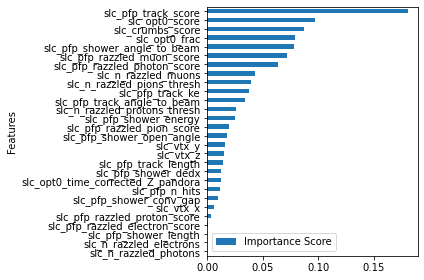

In [120]:
# Plot importance of features
importanceDF = pd.DataFrame({'Features': featureNames, 'Importance Score':baseBDT2.feature_importances_})
print (importanceDF.sort_values(by=['Importance Score']))
print('\n')
ax = importanceDF.sort_values(by=['Importance Score'])\
    .plot(kind='barh', x='Features', y='Importance Score')
plt.tight_layout()
plt.show()

In [79]:
# Print all tunable params
#baseBDT.get_params().keys()

[CV 4/5] END base_estimator__max_depth=1, n_estimators=100;, score=(train=0.957, test=0.960) total time=   5.4s
[CV 1/5] END base_estimator__max_depth=2, n_estimators=100;, score=(train=0.972, test=0.958) total time=  10.3s
[CV 4/5] END base_estimator__max_depth=2, n_estimators=250;, score=(train=0.974, test=0.969) total time=  26.4s
[CV 3/5] END base_estimator__max_depth=3, n_estimators=250;, score=(train=0.999, test=0.970) total time=  37.5s
[CV 5/5] END base_estimator__max_depth=1, n_estimators=50;, score=(train=0.957, test=0.953) total time=   2.5s
[CV 3/5] END base_estimator__max_depth=1, n_estimators=150;, score=(train=0.961, test=0.963) total time=   8.0s
[CV 2/5] END base_estimator__max_depth=2, n_estimators=100;, score=(train=0.972, test=0.961) total time=   8.9s
[CV 4/5] END base_estimator__max_depth=2, n_estimators=200;, score=(train=0.972, test=0.967) total time=  18.4s
[CV 2/5] END base_estimator__max_depth=3, n_estimators=200;, score=(train=0.996, test=0.965) total time= 

Optimal signif : 625157872.0
Optimal sigEff : 97.02885689870506
Optimal bkgRej : 94.41558731078761
Optimal binCut : 45
Optimal scoreCut : -0.1


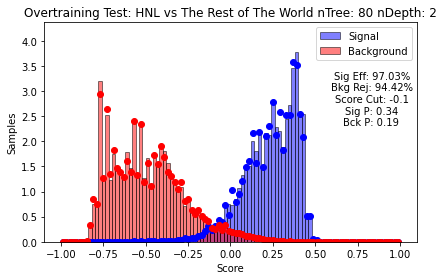

KS Signal:     0.01697689904801103 with P value: 0.3416928023936784
KS BackGround: 0.01136878554650711 with P value: 0.19482544322714168
[CV 2/5] END base_estimator__max_depth=1, n_estimators=50;, score=(train=0.955, test=0.953) total time=   2.6s
[CV 4/5] END base_estimator__max_depth=1, n_estimators=116;, score=(train=0.959, test=0.962) total time=   5.8s
[CV 2/5] END base_estimator__max_depth=2, n_estimators=83;, score=(train=0.968, test=0.961) total time=   7.7s
[CV 4/5] END base_estimator__max_depth=2, n_estimators=150;, score=(train=0.969, test=0.968) total time=  13.1s
[CV 5/5] END base_estimator__max_depth=3, n_estimators=116;, score=(train=0.985, test=0.966) total time=  15.0s
[CV 4/5] END base_estimator__max_depth=4, n_estimators=83;, score=(train=1.000, test=0.972) total time=  14.2s
[CV 4/5] END base_estimator__max_depth=1, n_estimators=50;, score=(train=0.955, test=0.957) total time=   2.7s
[CV 5/5] END base_estimator__max_depth=1, n_estimators=116;, score=(train=0.960, te

[CV 4/5] END base_estimator__max_depth=1, n_estimators=83;, score=(train=0.957, test=0.960) total time=   4.2s
[CV 4/5] END base_estimator__max_depth=1, n_estimators=150;, score=(train=0.960, test=0.962) total time=   7.7s
[CV 1/5] END base_estimator__max_depth=2, n_estimators=150;, score=(train=0.974, test=0.962) total time=  13.1s
[CV 5/5] END base_estimator__max_depth=3, n_estimators=83;, score=(train=0.978, test=0.966) total time=  10.5s
[CV 2/5] END base_estimator__max_depth=4, n_estimators=50;, score=(train=0.994, test=0.964) total time=   8.4s
[CV 3/5] END base_estimator__max_depth=4, n_estimators=83;, score=(train=1.000, test=0.973) total time=  14.2s
[CV 5/5] END base_estimator__max_depth=4, n_estimators=150;, score=(train=1.000, test=0.967) total time=  20.3s


In [121]:
parameters = {
  'ClassNames': ['Signal', 'Background'],
  'SignalDefinition': [1, 0],
  'PlotColors': ['b', 'r'],
  'nBins': 100,
  'PlotStep': 1.0,
  'OptimalBinCut': 0,
  'OptimalScoreCut': 0.0,
  'nTrees': input_n_trees,
  'TreeDepth': input_max_depth
}

FindOptimalSignificanceCut(baseBDT, xTest, yTest, parameters)
PlotBdtScores(baseBDT, xTest, yTest, xTrain, yTrain, 'HNL vs The Rest of The World nTree: '+ str(input_n_trees) +' nDepth: ' + str(input_max_depth), parameters)

#FindOptimalSignificanceCut(baseBDT2, xTest, yTest, parameters)
#PlotBdtScores(baseBDT2, xTest, yTest, xTrain, yTrain, 'PFO Characterisation nTree: '+ str(input_n_trees2) +' nDepth: ' + str(input_max_depth2), parameters)


In [45]:
BDTName = "TestBDT"
SerializeToPkl(BDTName+".pkl", baseBDT)